# Lab 2
## Ava Everett and Jay Lu



## Business Understanding

*Based on your selected dataset, prompt an LLM to generate a description of:*

 - the application domain,
 - the prediction task,
 - who would use the classifier,
 - whether the model is intended for deployment or analysis,
 - what level of performance would make the classifier useful.

*Provide the prompt you designed and the LLM response.*
*Identify at least two inaccuracies, omissions, or overly generic statements, and provide a corrected version of these inaccuracies (in your own words).*


Prompt: I am analyzing an anime dataset collected from compiling MyAnimeList.net (MAL) rankings. Generate a business-understanding summary that includes the application domain, the prediction task (using logistic regression on genres, number of platforms, source material, air year, MAL score and Anilist score) to predict whether a show will have a MAL popularity ranking in the top 5K, who would use the classifier, whether the model is intended for deployment or analysis, and what level of performance would make the classifier useful. Keep your response under 500 words. Here is a link to the dataset: (https://www.kaggle.com/datasets/rudrakumargupta/anime-dataset-20k-titles-and-dual-scores/code), and here is a link to the raw data: https://raw.githubusercontent.com/Lu-Rin-e/CS5324-Machine-Learning-Lab-1---Table-Data-Exploration/refs/heads/main/anime_dataset_20k.csv


Model used: Claude Sonnet 5 Medium

Response:

Here's the business-understanding summary:

---

#### Business Understanding Summary

**Application Domain**

The application domain is anime media analytics, using a dataset of roughly 20,000 titles compiled from MyAnimeList (MAL) and cross-referenced with AniList. Each record describes a title's genres, source material (manga, light novel, original, visual novel, etc.), air year, streaming availability, and community reception metrics (MAL score, MAL popularity rank, AniList score). This domain sits at the intersection of entertainment analytics and recommendation-adjacent research: understanding what characteristics are associated with an anime becoming widely watched and discussed, as distinct from being merely well-rated.

**Prediction Task**

The task is a binary classification problem: predict whether a given anime's MAL popularity ranking falls within the top 5,000 titles (popular = 1) or not (popular = 0). Popularity rank on MAL is driven primarily by member/watcher counts, so this is a proxy for "reach" or audience size rather than quality. A logistic regression model will be trained using genre indicators, number of streaming platforms (`num_platforms`), source material type, air year, MAL score, and AniList score as predictors. Logistic regression is appropriate here because the target is binary, the predictors are a mix of categorical and continuous features, and the model's coefficients offer directly interpretable odds-ratios — useful for explaining *why* a show is predicted to be popular, not just *that* it is.

**Intended Users**

Likely users include anime streaming platforms and licensors (evaluating acquisition or localization candidates), marketing or content strategy teams at studios, data-driven fan communities or review aggregators, and researchers studying media consumption trends. A user might ask: "Does licensing this manga-adapted show to more platforms meaningfully raise its odds of breaking into the top 5K, holding quality scores constant?"

**Deployment vs. Analysis**

This model is intended for **analysis, not production deployment**. The goal is explanatory and exploratory: understanding which factors (genre mix, platform reach, source material, era, critical reception) correlate with mainstream popularity, and by how much. It is not intended to serve real-time predictions in a live product, trigger automated licensing decisions, or be embedded in a recommendation pipeline. Any deployment use would require revalidation, monitoring for drift (e.g., new streaming platforms, shifting genre trends), and ideally a more flexible model class.

**Useful Performance Threshold**

Because "top 5K out of ~20K" is a roughly 25% base rate, a naive majority-class classifier would already achieve ~75% accuracy by always predicting "not popular." For the model to be genuinely useful for analysis, it should therefore exceed that baseline meaningfully — a reasonable bar is **AUC ≥ 0.75** and **F1 ≥ 0.55–0.60** on the minority (popular) class, since accuracy alone would be misleading given the class imbalance. Given the analytical (not operational) purpose, precision/recall need not meet a strict deployment SLA; what matters most is that coefficient signs and magnitudes are stable and interpretable, so stakeholders can trust the *direction* and *relative size* of each factor's association with popularity, even if individual predictions aren't perfectly accurate.



### Issues

Overall, it's a pretty good response. The application domain is spot on, and it correctly idenfitied that this model would be better suited for analysis. I appreciate that it correctly identifies where "popularity" comes from on MAL and how it is not necessarily tied to MAL Rank. It does list many intended users that could all benefit from this model, but that does leave me to narrow it down to one or two potential options. I find it interesting that Claude failed to mention the user of third-party companies looking to host brand deals with these shows in the West, as whether a brand deal is good or not relies more on the popularity of the media than the quality. The useful performance threshold is also very insightful, but the generalization of "stakeholders" is pretty vague when it could have given a case-by-case basis for each of the intended user types it idenfitied earlier. One more thing, it failed to mention the implications of having to clean the dataset and removing titles may skew the percent from 25/75 to a closer 50/50. 


### Rewrite


#### Business Understanding Summary

**Application Domain**

The application domain falls within entertainment analytics, more specifically in the anime-related field. This model utilizes a dataset of approximately 20 thousand titles compiled from MyAnimeList (MAL), a user-curated anime ranking site, and cross-referenced with AniList, a similar website. Each record holds a variety of information from anime title and synopsis to genres, source material, air year, and streaming availibility. Rather than just discussing whether an anime is highly rated, this dataset also holds information as to how popular/widespread the anime is in Western markets.

**Prediction Task**

The task is a binary classification problem: predict whether a given anime's MAL popularity ranking falls within the top 5,000 titles (popular = 1) or not (popular = 0). Popularity rank on MAL is driven primarily by member/watcher counts, so this is a proxy for "reach" or audience size rather than quality. A logistic regression model will be trained using genre indicators, number of streaming platforms (`num_platforms`), source material type, air year, MAL score, and AniList score as predictors. Logistic regression is appropriate here because the target is binary, the predictors are a mix of categorical and continuous features, and the model's coefficients offer directly interpretable odds-ratios — useful for explaining *why* a show is predicted to be popular, not just *that* it is.

The task is a binary classification problem to predict whether a given anime's MAL popularity ranking falls within the top 5,000 titles (popular = 1) or not (popular = 0). Popularity rank on MAL is independent from an anime's general rank; while general rank is a metric of the anime's quality by uer reviews, popularity is determined by "the number of users who have added the entry to their list," according to MAL's website. This is a better representation of the number of people who have watched the anime, which in turn is a better indicator of if an anime is popular in the West. For example, the popular series *My Hero Academia* has score of 7.82 and a rank of 1111, but it has a popularity rank of 6, showing how well-known it is to Western audiences.

A logistic regression model will be trained using genre indicators, number of streaming platforms, source material type, air year, MAL score, and AniList score as predictors. Logistic regression is perfect because this is a binary classification problem where there are only two options: popular or not popular, and also because the predictors are a mix of categorical and continuous features. It is also helpful that the model's coefficients offer easily interpretable odds-ratios, such as being able to pinpoint to what extent how much each streaming platform a show has increases the odds of the show being popular.

**Intended Users**

Although there are many possible users for this particular dataset, we'll be focusing on companies looking to have collaborative (aka: collab) events with Japanese anime francises/sell anime-themed merchandise, such as Round1 or Hot Topic. These companies have to plan what they stock to cater to Western anime fans. In Round1's case, they have a Japanese branch and an American branch, so knowing which collabs to bring to the West is key to keep retention and inspire new customers. 

**Deployment vs. Analysis**

This model is intended for analysis; by analyzing current trends in media that determines popularity, these factors can be utilized to predict future anime's scores. However, since some of the data it relies on like MAL and AniList scores can't be determined until the anime airs, it wouldn't be as useful for live deployment. Using this model for live deployment would also be hindered by changes in streaming platforms or genre trends and would need to be retrained. 

**Useful Performance Threshold**

As the top 5K anime already takes up about 25% of the current dataset, a classifier that just says everything is below 5K would be 75% correct. For the model to be of actual value, it needs to have an area under the ROC curve (AUC) of >= 0.75 and an F1 >= 0.55-0.6 on the minority class rather than the majority class. This is assuming that none of the data will be removed, which is false since some anime in certain categories (e.g., R18+ and Music Videos) do not have a popularity ranking. In that case, the AOC can continue to be >= 0.75, but the F1 has to be >= 0.65 - 0.7 because the classes are more balanced. Since the purpose of this model is analysis, it's more important that the coefficients as to whether or not something positively or negatively impacts popularity are trustworthy rather than actual individual classifications of the data so that  companies like Round1 can see the individual components to a show's popularity. 




## Data Preparation

*Without assistance from an LLM, prepare the dataset. The purpose of this section is to demonstrate that you understand how logistic regression operates on numerical feature representations. All preparation decisions should be justified. You should:*

- encode categorical variables,
- normalize or standardize features where appropriate,
- remove unnecessary variables,
- summarize the final dataset after preprocessing.

In [1]:
# Loading the anime dataset

import pandas as pd
import numpy as np

print ('Pandas:', pd.__version__)
print('Numpy:', np.__version__)

df = pd.read_csv('https://raw.githubusercontent.com/Lu-Rin-e/CS5324-Machine-Learning-Lab-1---Table-Data-Exploration/refs/heads/main/anime_dataset_20k.csv')
df.head()

Pandas: 2.2.2
Numpy: 1.26.4


,mal_id,anilist_id,title_english,title_romaji,title_japanese,title_synonyms,type,source,status,age_rating,...,is_disney_plus,is_hulu,is_vrv,is_bilibili,is_youtube,num_platforms,score_tier,popularity_tier,synopsis,image_url
0,1,1.0,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,NaN,TV,original,finished_airing,r,...,False,True,False,False,False,6,Great,Top 100,"Crime is timeless. By the year 2071, humanity ...",https://cdn.myanimelist.net/images/anime/4/196...
1,5,5.0,Cowboy Bebop: The Movie,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: Knockin' on Heaven's Door,MOVIE,original,finished_airing,r,...,False,False,False,False,False,0,Great,Top 1K,"Another day, another bounty—such is the life o...",https://cdn.myanimelist.net/images/anime/1439/...
2,6,6.0,Trigun,Trigun,トライガン,NaN,TV,manga,finished_airing,pg_13,...,False,False,False,False,False,1,Great,Top 500,"Vash the Stampede is the man with a $$60,000,0...",https://cdn.myanimelist.net/images/anime/1130/...
3,7,7.0,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),WHR,TV,original,finished_airing,pg_13,...,False,False,False,False,False,1,Good,Top 5K,"Though hidden away from the general public, Wi...",https://cdn.myanimelist.net/images/anime/10/19...
4,8,8.0,Beet the Vandel Buster,Bouken Ou Beet,冒険王ビィト,Adventure King Beet,TV,manga,finished_airing,pg,...,False,False,False,False,False,0,Average,Niche,It is the dark century and the people are suff...,https://cdn.myanimelist.net/images/anime/7/215...


According to MAL's website, all R18+ anime and all music videos are excluded from the ranking, so we'll be removing them here. To also consolidate the data, we'll be focusing on anime shows and movies as well, exlcuding nicher anime types like OVAs, ONAs, etc.

In [2]:
# Removing Adult/Explicit Anime
df = df[df.is_adult == False]

#Removing is_adult column
del df['is_adult']

# Removing all items that aren't TV shows or Movies
df = df[(df.type == 'TV') | (df.type == 'MOVIE')]



Now, we'll be removing all the columns we don't need. The only columns needed are:
- type
- source
- year
- mal_score
- anilist_score
- mal_popularity
- streaming_platforms
- genres

In [3]:
keep_cols = ['type', 'source', 'year', 'mal_score', 'anilist_score', 'mal_popularity', 'num_platforms', 'genres']
df = df[keep_cols]
df.head()

,type,source,year,mal_score,anilist_score,mal_popularity,num_platforms,genres
0,TV,original,1998.0,8.75,8.6,41,6,Action | Adult Cast | Award Winning | Sci-Fi |...
1,MOVIE,original,2001.0,8.38,8.2,663,0,Action | Adult Cast | Sci-Fi | Space
2,TV,manga,1998.0,8.22,8.0,268,1,Action | Adult Cast | Adventure | Sci-Fi | Sho...
3,TV,original,2002.0,7.24,6.8,2002,1,Action | Detective | Drama | Mystery | Superna...
4,TV,manga,2004.0,6.97,6.5,6003,0,Action | Adventure | Fantasy | Shounen


Next, we need to multi-hot encode the genres and add a row to determine if an anime is in the top 5K or not.

In [ ]:
#Multi-hot Encoding the Genres; they are currently one object
from sklearn.preprocessing import MultiLabelBinarizer

genre_lists = df['genres'].str.split('|').apply(lambda lst: [g.strip() for g in lst])

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(genre_lists),
    columns=mlb.classes_,
    index=df.index
)

# The dataset combined MAL Themes, MAL Genres, and Demographics into genres. Just keeping the Genres and Demographics
genres_to_keep = [
    'Action', 'Adventure', 'Avant Garde', 'Boys Love',
    'Comedy', 'Drama', 'Fantasy', 'Girls Love', 'Gourmet', 'Horror',
    'Mystery', 'Romance', 'Sci-Fi', 'Slice of Life', 'Sports',
    'Supernatural', 'Suspense', 'Josei', 'Kids', 'Seinen', 'Shoujo', 'Shounen'
]

# Filtering the encoded columns before merging into dataframe
genre_encoded = genre_encoded[[col for col in genre_encoded.columns if col in genres_to_keep]]

df = pd.concat([df, genre_encoded], axis=1)


df['popular'] = (df['mal_popularity'] <= 5000).astype(int)

#Getting rid of old genres column
del df['genres']

#Checking what the cleaned data looks like
df.to_csv('animecleaned2.csv', index=False)



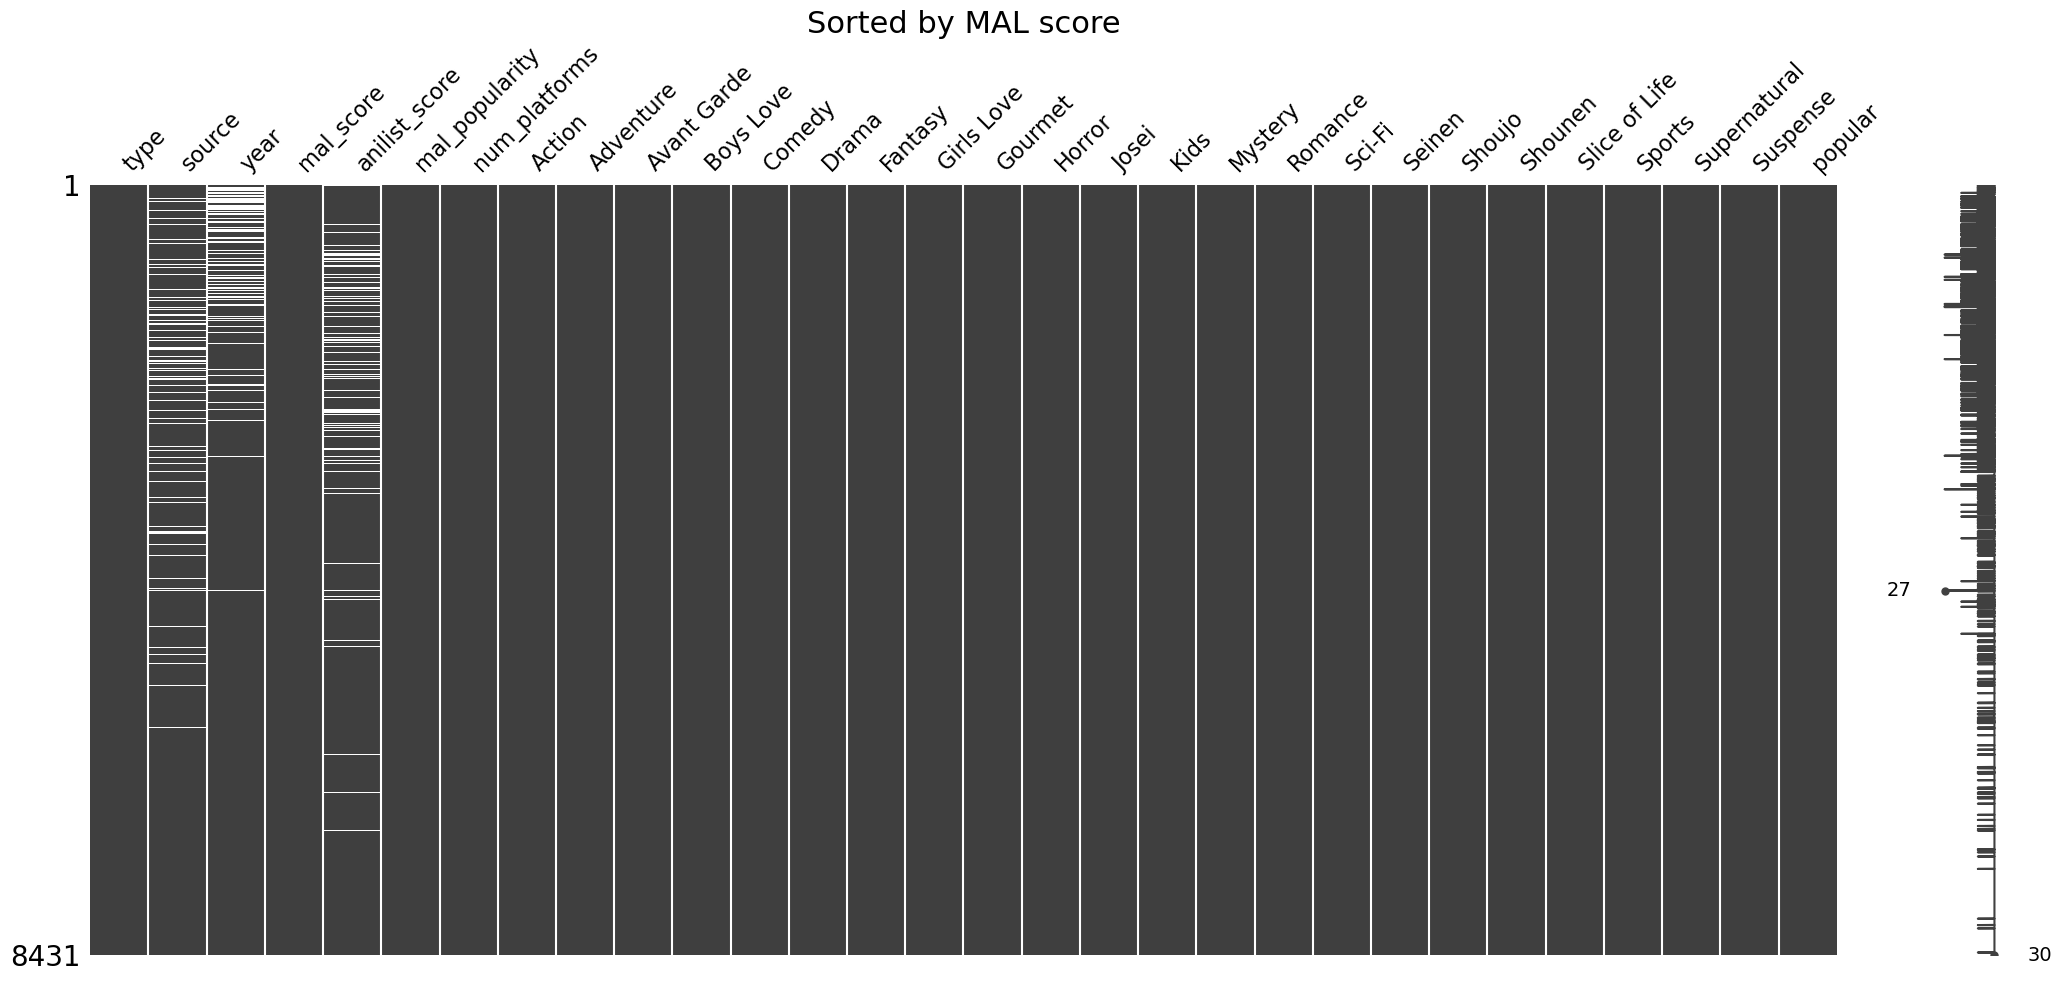

In [6]:
# Seeing how much data is missing
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline

import missingno as mn
mn.matrix(df.sort_values(by=['mal_score']))
plt.title("Sorted by MAL score", fontsize=22)
plt.show()

#### Summary of the data set

Now, we have a data set that has:
- Anime Type (movie or tv show)
- Source (What the anime was adapted from. E.g., manga, original, light novel, etc.)
- Year (When the anime was released. E.g., 2002)
- MAL Score (The show's score out of ten on MAL. E.g., 6.8)
- AniList Score (The show's score out of ten on AniList. E.g., 6.8)
- MAL Popularity (the show's popularity on MAL. E.g., 253)
- Number of Platforms (the number of streaming services the show is available on. E.g., 6)
- Genre multi-hot encoded columns (Have 1 or 0 depending if the show has that genre)
- Popular (Whether the show is in the top 5000 in MAL or not. Has 1 or 0)

In [ ]:
# Finding what percent of the dataset has a popularity score of 5000 or less (popular)
print (df['popular'].value_counts(normalize=True)[1] * 100)



43.838216107223346


With the cleaning of the data, 43% of the data is in the top 5K, making it closer to a 50/50 split